# ROD Binary Ground / Non-ground Segmentation on RUGD — In-domain Training and Evaluation

This notebook is the **RUGD-only** version extracted from the previous combined ROD notebook.

It performs:
1. RUGD train / validation / test loading;
2. ROD training on RUGD;
3. best-checkpoint selection by validation mIoU;
4. final RUGD test evaluation using dataset-level metrics;
5. inference-speed measurement;
6. Top-5 / Bottom-5 per-image ranking;
7. unified five-column qualitative visualisation;
8. JSON / CSV / histogram output.

RELLIS-3D, cross-dataset evaluation, vegetation-specific metrics, and transfer-analysis code have been removed.

In [1]:
# Must be set before importing torch.
import os
import sys

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_SHOW_CPP_STACKTRACES"] = "1"

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)
print("CUDA_LAUNCH_BLOCKING:", os.environ.get("CUDA_LAUNCH_BLOCKING"))

Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 9.58 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg
CUDA_LAUNCH_BLOCKING: 1


In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import sys
import shutil
import zipfile
import random
import warnings
import time
import gc
import json

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A

warnings.filterwarnings("ignore")

SEED = 42

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 1. RUGD paths and output directories

In [3]:
# Keep the existing RUGD data paths unchanged.
IRP_ROOT = Path("/content/drive/MyDrive/IRP/01_data")

def extract_zip(zip_path: Path, output_root: Path):
    if not zip_path.exists():
        raise FileNotFoundError(zip_path)
    output_root.mkdir(parents=True, exist_ok=True)
    print("Extracting:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(output_root)
    print("Done:", output_root)

RUGD_PROCESSED_ZIP = IRP_ROOT / "processed/RUGD_processed.zip"

RUGD_PROCESSED_ROOT = Path("/content/content/RUGD_processed")
if not RUGD_PROCESSED_ROOT.exists():
    extract_zip(RUGD_PROCESSED_ZIP, Path("/content"))

# Required output roots.
CHECKPOINT_DIR = Path("/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints")
RESULTS_ROOT = Path("/content/drive/MyDrive/IRP/02_in_domain_rugd/results")

# Keep ROD result files grouped so they do not overwrite other models.
RESULTS_DIR = RESULTS_ROOT / "rod_20epochs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for name, path in {
    "RUGD processed": RUGD_PROCESSED_ROOT,
    "RUGD train": RUGD_PROCESSED_ROOT / "images" / "train",
    "RUGD val": RUGD_PROCESSED_ROOT / "images" / "val",
    "RUGD test": RUGD_PROCESSED_ROOT / "images" / "test",
    "Checkpoint dir": CHECKPOINT_DIR,
    "Results dir": RESULTS_DIR,
}.items():
    print(f"{name:18s} | exists={path.exists()} | {path}")

Extracting: /content/drive/MyDrive/IRP/01_data/processed/RUGD_processed.zip
Done: /content
RUGD processed     | exists=True | /content/content/RUGD_processed
RUGD train         | exists=True | /content/content/RUGD_processed/images/train
RUGD val           | exists=True | /content/content/RUGD_processed/images/val
RUGD test          | exists=True | /content/content/RUGD_processed/images/test
Checkpoint dir     | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints
Results dir        | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/results/rod_20epochs


## 2. Training configuration

In [4]:
IMAGE_SIZE = 512

# Keep the current ROD training configuration.
# The EfficientSAM encoder internally uses 1024 x 1024 input.
BATCH_SIZE = 1
NUM_WORKERS = 0

EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
POLY_POWER = 0.9
PATIENCE = 6

USE_AMP = False
FREEZE_ENCODER = True

IGNORE_INDEX = 255
NUM_CLASSES = 2

NON_GROUND_ID = 0
GROUND_ID = 1

# No gradient accumulation: effective batch size = 1.
GRAD_ACCUM_STEPS = 1

MODEL_NAME = "ROD"
ENCODER_NAME = "EfficientSAM-S"

best_model_path = CHECKPOINT_DIR / "rod_rugd_binary_ground_best_20epochs.pth"

print("Best checkpoint:", best_model_path)

Best checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth


## 3. ROD model

In [5]:
WEIGHTS_DIR = Path(ROD_REPO) / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_ZIP = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"
VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        !wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O {WEIGHTS_ZIP}

    with zipfile.ZipFile(WEIGHTS_ZIP, "r") as archive:
        archive.extractall(WEIGHTS_DIR)

if not VITS_PATH.exists():
    raise FileNotFoundError(f"EfficientSAM-S checkpoint not found: {VITS_PATH}")

print("EfficientSAM-S checkpoint:", VITS_PATH)

from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead


def load_encoder(checkpoint_path):
    checkpoint_path = Path(checkpoint_path).resolve()

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"EfficientSAM checkpoint not found: {checkpoint_path}")

    efficient_sam_dir = Path(ROD_REPO) / "efficient_sam"
    expected_checkpoint = (
        efficient_sam_dir / "weights" / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(checkpoint_path, expected_checkpoint)

    previous_cwd = Path.cwd()
    try:
        os.chdir(efficient_sam_dir)
        efficient_sam_model = build_efficient_sam_vits()
    finally:
        os.chdir(previous_cwd)

    return efficient_sam_model.image_encoder


class ROD(nn.Module):
    def __init__(self, checkpoint_path, freeze=True):
        super().__init__()
        self.encoder = load_encoder(checkpoint_path)
        self.decoder = SegHead()
        self.freeze = freeze
        self.encoder_input_size = int(self.encoder.img_size)

        if self.freeze:
            for parameter in self.encoder.parameters():
                parameter.requires_grad = False
            self.encoder.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze:
            self.encoder.eval()
        return self

    def forward(self, x):
        output_size = x.shape[-2:]

        if x.shape[-2:] != (self.encoder_input_size, self.encoder_input_size):
            encoder_x = F.interpolate(
                x,
                size=(self.encoder_input_size, self.encoder_input_size),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(encoder_x.float())
        else:
            features = self.encoder(encoder_x.float())

        if torch.is_tensor(features):
            features = features.float()
        elif isinstance(features, (list, tuple)):
            features = [
                feature.float() if torch.is_tensor(feature) else feature
                for feature in features
            ]
        elif isinstance(features, dict):
            features = {
                key: (value.float() if torch.is_tensor(value) else value)
                for key, value in features.items()
            }

        # Keep the original workaround used by the current ROD notebook.
        with torch.backends.cudnn.flags(enabled=False):
            logits = self.decoder(features)

        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_rod_model():
    return ROD(
        checkpoint_path=VITS_PATH,
        freeze=FREEZE_ENCODER,
    )


model = build_rod_model().to(DEVICE)

print("Encoder input size:", model.encoder_input_size)
print(
    "Total parameters (M):",
    sum(p.numel() for p in model.parameters()) / 1e6,
)
print(
    "Trainable parameters (M):",
    sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6,
)

/content/offroad_ro 100%[===================>]  93.75M   338MB/s    in 0.3s    
EfficientSAM-S checkpoint: /content/offroad_roadseg/efficient_sam/weights/efficient_sam_vits.pt
Encoder input size: 1024
Total parameters (M): 29.369218
Trainable parameters (M): 7.015554


## 4. RUGD binary label mapping

In [6]:
# Preserve the mapping from the current ROD notebook.
RUGD_TRAIN_ID_TO_CLASS = {
    0: "dirt",
    1: "sand",
    2: "grass",
    3: "tree",
    4: "pole",
    5: "water",
    6: "sky",
    7: "vehicle",
    8: "container_generic_object",
    9: "asphalt",
    10: "gravel",
    11: "building",
    12: "mulch",
    13: "rock_bed",
    14: "log",
    15: "bicycle",
    16: "person",
    17: "fence",
    18: "bush",
    19: "sign",
    20: "rock",
    21: "bridge",
    22: "concrete",
    23: "picnic_table",
}

RUGD_GROUND_TRAIN_IDS = {
    0,   # dirt
    1,   # sand
    2,   # grass
    9,   # asphalt
    10,  # gravel
    12,  # mulch
    13,  # rock-bed
    22,  # concrete
}

# Unified with the U-Net, DeepLabV3+, and SegFormer-B0 baselines:
# sky (6) is treated as non-ground.
# Only water (5), bridge (21), and original void/unknown (255) are ignored.
RUGD_IGNORE_TRAIN_IDS = {
    5,   # water
    21,  # bridge
    255, # original void / unknown
}

RUGD_VALID_TRAIN_IDS = set(range(24)) | {IGNORE_INDEX}

BINARY_ID_TO_CLASS = {
    0: "non-ground",
    1: "ground",
}


def read_rgb(path: Path):
    return np.array(Image.open(path).convert("RGB"))


def read_id_mask(path: Path):
    image = Image.open(path)
    array = np.array(image)

    if array.ndim == 3:
        raise ValueError(
            "Expected a single-channel ID mask, but received "
            f"shape={array.shape}; path={path}"
        )

    return array.astype(np.uint8)


def rugd_train_id_to_binary(train_id_mask: np.ndarray) -> np.ndarray:
    train_id_mask = np.asarray(train_id_mask, dtype=np.uint8)

    unique_values = set(np.unique(train_id_mask).tolist())
    unknown_values = unique_values - RUGD_VALID_TRAIN_IDS

    if unknown_values:
        raise ValueError(
            "Unknown RUGD processed train IDs: "
            f"{sorted(unknown_values)}"
        )

    # All non-ground train IDs start as 0.
    binary_mask = np.full(
        train_id_mask.shape,
        NON_GROUND_ID,
        dtype=np.uint8,
    )

    binary_mask[
        np.isin(train_id_mask, list(RUGD_GROUND_TRAIN_IDS))
    ] = GROUND_ID

    binary_mask[
        np.isin(train_id_mask, list(RUGD_IGNORE_TRAIN_IDS))
    ] = IGNORE_INDEX

    mapped_values = set(np.unique(binary_mask).tolist())
    allowed = {NON_GROUND_ID, GROUND_ID, IGNORE_INDEX}

    if not mapped_values.issubset(allowed):
        raise ValueError(
            f"Invalid mapped RUGD binary values: {sorted(mapped_values - allowed)}"
        )

    return binary_mask

## 5. RUGD train / val / test records

In [7]:
def build_rugd_records(split: str):
    image_dir = RUGD_PROCESSED_ROOT / "images" / split
    mask_dir = RUGD_PROCESSED_ROOT / "masks" / split

    image_paths = sorted(
        list(image_dir.glob("*.png"))
        + list(image_dir.glob("*.jpg"))
        + list(image_dir.glob("*.jpeg"))
    )

    rows = []
    for image_path in image_paths:
        mask_path = mask_dir / f"{image_path.stem}.png"

        if not mask_path.exists():
            raise FileNotFoundError(mask_path)

        rows.append({
            "dataset": "RUGD",
            "split": split,
            "image_path": str(image_path),
            "binary_mask_path": str(mask_path),
        })

    return pd.DataFrame(rows)


rugd_train_records = build_rugd_records("train")
rugd_val_records = build_rugd_records("val")
rugd_test_records = build_rugd_records("test")

print("RUGD train:", len(rugd_train_records))
print("RUGD val:", len(rugd_val_records))
print("RUGD test:", len(rugd_test_records))

RUGD train: 4859
RUGD val: 1095
RUGD test: 1482


## 6. Dataset and augmentation

In [8]:
PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)

PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4,
    ),
    A.HueSaturationValue(
        hue_shift_limit=6,
        sat_shift_limit=10,
        val_shift_limit=8,
        p=0.25,
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.10,
    ),
])


def resize_pad(image, mask, size=IMAGE_SIZE):
    h, w = image.shape[:2]
    scale = size / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    image = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR,
    )
    mask = cv2.resize(
        mask,
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST,
    )

    top = (size - new_h) // 2
    bottom = size - new_h - top
    left = (size - new_w) // 2
    right = size - new_w - left

    image = cv2.copyMakeBorder(
        image,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0),
    )
    mask = cv2.copyMakeBorder(
        mask,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=IGNORE_INDEX,
    )

    return image, mask


def normalize_image(image):
    image = (image.astype(np.float32) - PIXEL_MEAN) / PIXEL_STD
    return (
        torch.from_numpy(image)
        .permute(2, 0, 1)
        .contiguous()
    )


class RUGDBinaryDataset(Dataset):
    def __init__(self, records, training=False):
        self.records = records.reset_index(drop=True)
        self.training = training
        self.image_paths = [
            Path(p) for p in self.records["image_path"].tolist()
        ]

        if len(self.records) == 0:
            raise ValueError("Dataset records are empty.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records.iloc[index]

        image = read_rgb(Path(row["image_path"]))
        raw_mask = read_id_mask(Path(row["binary_mask_path"]))
        mask = rugd_train_id_to_binary(raw_mask)

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                "Image/mask shape mismatch: "
                f"{row['image_path']} {image.shape[:2]} vs "
                f"{row['binary_mask_path']} {mask.shape[:2]}"
            )

        if self.training:
            transformed = train_aug(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        image, mask = resize_pad(image, mask)

        image = normalize_image(image)
        mask = torch.from_numpy(mask.astype(np.int64))

        return image, mask


train_dataset = RUGDBinaryDataset(rugd_train_records, training=True)
val_dataset = RUGDBinaryDataset(rugd_val_records, training=False)
test_dataset = RUGDBinaryDataset(rugd_test_records, training=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

images, masks = next(iter(train_loader))
print("Image batch:", images.shape)
print("Mask batch:", masks.shape)
print("Mapped mask values:", torch.unique(masks).tolist())

with torch.no_grad():
    test_logits = model(images[:1].to(DEVICE).float())

print("ROD output shape:", test_logits.shape)

assert test_logits.shape == (
    1,
    NUM_CLASSES,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

Train dataset: 4859
Val dataset: 1095
Test dataset: 1482
Image batch: torch.Size([1, 3, 512, 512])
Mask batch: torch.Size([1, 512, 512])
Mapped mask values: [0, 1, 255]
ROD output shape: torch.Size([1, 2, 512, 512])


## 7. Full RUGD mask audit

In [9]:
ALLOWED_BINARY_VALUES = {
    NON_GROUND_ID,
    GROUND_ID,
    IGNORE_INDEX,
}


def validate_record_masks(records, split_name):
    raw_union_values = set()
    binary_union_values = set()
    invalid_rows = []

    for index, row in tqdm(
        records.iterrows(),
        total=len(records),
        desc=f"Checking RUGD {split_name}",
    ):
        try:
            raw_mask = read_id_mask(Path(row["binary_mask_path"]))
            raw_values = set(np.unique(raw_mask).tolist())
            raw_union_values.update(raw_values)

            binary_mask = rugd_train_id_to_binary(raw_mask)
            binary_values = set(np.unique(binary_mask).tolist())
            binary_union_values.update(binary_values)

            invalid_binary = binary_values - ALLOWED_BINARY_VALUES
            if invalid_binary:
                invalid_rows.append({
                    "index": index,
                    "path": row["binary_mask_path"],
                    "raw_values": sorted(raw_values),
                    "binary_values": sorted(binary_values),
                    "error": f"Invalid mapped values: {sorted(invalid_binary)}",
                })

        except Exception as error:
            invalid_rows.append({
                "index": index,
                "path": row["binary_mask_path"],
                "raw_values": None,
                "binary_values": None,
                "error": repr(error),
            })

    print(f"RUGD {split_name} raw values:", sorted(raw_union_values))
    print(f"RUGD {split_name} mapped values:", sorted(binary_union_values))
    print(f"RUGD {split_name} invalid masks:", len(invalid_rows))

    if invalid_rows:
        invalid_df = pd.DataFrame(invalid_rows)
        display(invalid_df.head(20))
        raise ValueError(f"RUGD {split_name} mask validation failed.")


validate_record_masks(rugd_train_records, "train")
validate_record_masks(rugd_val_records, "val")
validate_record_masks(rugd_test_records, "test")

print("All RUGD masks passed mapping validation.")

Checking RUGD train:   0%|          | 0/4859 [00:00<?, ?it/s]

RUGD train raw values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 255]
RUGD train mapped values: [0, 1, 255]
RUGD train invalid masks: 0


Checking RUGD val:   0%|          | 0/1095 [00:00<?, ?it/s]

RUGD val raw values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 255]
RUGD val mapped values: [0, 1, 255]
RUGD val invalid masks: 0


Checking RUGD test:   0%|          | 0/1482 [00:00<?, ?it/s]

RUGD test raw values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 255]
RUGD test mapped values: [0, 1, 255]
RUGD test invalid masks: 0
All RUGD masks passed mapping validation.


## 8. Optimizer, loss, and metric accumulation

In [10]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

optimizer_steps_per_epoch = max(
    1,
    int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS)),
)

total_optimizer_steps = max(
    1,
    EPOCHS * optimizer_steps_per_epoch,
)


def new_stats():
    return {
        "intersection": np.zeros(NUM_CLASSES, dtype=np.float64),
        "union": np.zeros(NUM_CLASSES, dtype=np.float64),
        "tp": np.zeros(NUM_CLASSES, dtype=np.float64),
        "fp": np.zeros(NUM_CLASSES, dtype=np.float64),
        "fn": np.zeros(NUM_CLASSES, dtype=np.float64),
        "correct": 0,
        "valid": 0,
    }


def update_stats(stats, pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    valid = target_np != IGNORE_INDEX

    stats["correct"] += int(((pred_np == target_np) & valid).sum())
    stats["valid"] += int(valid.sum())

    for cls in range(NUM_CLASSES):
        pred_cls = (pred_np == cls) & valid
        target_cls = (target_np == cls) & valid

        cls_tp = np.logical_and(pred_cls, target_cls).sum()
        cls_fp = np.logical_and(pred_cls, np.logical_not(target_cls) & valid).sum()
        cls_fn = np.logical_and(np.logical_not(pred_cls) & valid, target_cls).sum()

        stats["tp"][cls] += cls_tp
        stats["fp"][cls] += cls_fp
        stats["fn"][cls] += cls_fn
        stats["intersection"][cls] += cls_tp
        stats["union"][cls] += np.logical_or(pred_cls, target_cls).sum()


def metrics_from_stats(stats):
    class_iou = {}
    for cls in range(NUM_CLASSES):
        class_iou[cls] = (
            float(stats["intersection"][cls] / stats["union"][cls])
            if stats["union"][cls] > 0 else None
        )

    valid_ious = [v for v in class_iou.values() if v is not None]

    return {
        "non_ground_iou": class_iou[0],
        "ground_iou": class_iou[1],
        "miou": float(np.mean(valid_ious)) if valid_ious else 0.0,
        "pixel_accuracy": (
            float(stats["correct"] / stats["valid"])
            if stats["valid"] > 0 else 0.0
        ),
    }


print("Trainable parameter tensors:", len(optimizer.param_groups[0]["params"]))
print("Gradient accumulation:", GRAD_ACCUM_STEPS)

Trainable parameter tensors: 174
Gradient accumulation: 1


## 9. RUGD training and validation

In [11]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    stats = new_stats()

    for images, masks in tqdm(loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True).float()
        masks = masks.to(device, non_blocking=True).long()

        logits = model(images)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)

        update_stats(stats, preds, masks)
        total_loss += float(loss.item()) * images.size(0)

    metrics = metrics_from_stats(stats)
    metrics["loss"] = total_loss / max(len(loader.dataset), 1)
    return metrics


history = {
    "train_loss": [],
    "val_loss": [],
    "val_miou": [],
    "non_ground_iou": [],
    "ground_iou": [],
}

best_val_miou = -1.0
stale_epochs = 0
optimizer_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_stats = new_stats()
    total_train_loss = 0.0

    optimizer.zero_grad(set_to_none=True)

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS}",
    )

    for batch_index, (images, masks) in enumerate(progress):
        images = images.to(DEVICE, non_blocking=True).float()
        masks = masks.to(DEVICE, non_blocking=True).long()

        learning_rate = (
            LEARNING_RATE
            * max(
                0.0,
                1.0 - optimizer_step / total_optimizer_steps,
            )
            ** POLY_POWER
        )

        for group in optimizer.param_groups:
            group["lr"] = learning_rate

        logits = model(images)

        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        raw_loss = criterion(logits, masks)
        (raw_loss / GRAD_ACCUM_STEPS).backward()

        should_step = (
            ((batch_index + 1) % GRAD_ACCUM_STEPS == 0)
            or ((batch_index + 1) == len(train_loader))
        )

        if should_step:
            torch.nn.utils.clip_grad_norm_(
                [
                    p for p in model.parameters()
                    if p.requires_grad and p.grad is not None
                ],
                max_norm=1.0,
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_step += 1

        preds = logits.detach().argmax(dim=1)
        update_stats(train_stats, preds, masks)

        total_train_loss += float(raw_loss.item()) * images.size(0)

        progress.set_postfix(
            loss=f"{raw_loss.item():.4f}",
            lr=f"{learning_rate:.2e}",
        )

    train_metrics = metrics_from_stats(train_stats)
    train_loss = total_train_loss / max(len(train_loader.dataset), 1)

    val_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_miou"].append(val_metrics["miou"])
    history["non_ground_iou"].append(val_metrics["non_ground_iou"])
    history["ground_iou"].append(val_metrics["ground_iou"])

    print(f"Epoch [{epoch}/{EPOCHS}]")
    print(f"Train Loss:     {train_loss:.4f}")
    print(f"Val Loss:       {val_metrics['loss']:.4f}")
    print(f"Val mIoU:       {val_metrics['miou']:.4f}")
    print(
        f"Non-ground IoU: {val_metrics['non_ground_iou']:.4f}"
        if val_metrics["non_ground_iou"] is not None
        else "Non-ground IoU: None"
    )
    print(
        f"Ground IoU:     {val_metrics['ground_iou']:.4f}"
        if val_metrics["ground_iou"] is not None
        else "Ground IoU: None"
    )

    if val_metrics["miou"] > best_val_miou:
        best_val_miou = val_metrics["miou"]
        stale_epochs = 0

        checkpoint = {
            "epoch": epoch,
            "epochs_configured": EPOCHS,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_miou": best_val_miou,
            "num_classes": NUM_CLASSES,
            "encoder_name": ENCODER_NAME,
            "ignore_index": IGNORE_INDEX,
            "binary_id_to_class": BINARY_ID_TO_CLASS,
            "ground_ids_from_24class": sorted(RUGD_GROUND_TRAIN_IDS),
            "ignore_ids_from_24class": sorted(RUGD_IGNORE_TRAIN_IDS),
            "image_size": IMAGE_SIZE,
            "encoder_input_size": model.encoder_input_size,
            "history": history,
        }

        torch.save(checkpoint, best_model_path)
        print(f"Saved best model to: {best_model_path}")
    else:
        stale_epochs += 1

        if stale_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (patience={PATIENCE}).")
            break

print(f"Training complete. Best validation mIoU: {best_val_miou:.4f}")
print("Best checkpoint:", best_model_path)

Epoch 1/20:   0%|          | 0/4859 [00:00<?, ?it/s]

Validation:   0%|          | 0/1095 [00:00<?, ?it/s]

Epoch [1/20]
Train Loss:     0.0959
Val Loss:       0.0735
Val mIoU:       0.9462
Non-ground IoU: 0.9511
Ground IoU:     0.9413
Saved best model to: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth


Epoch 2/20:   0%|          | 0/4859 [00:00<?, ?it/s]

Validation:   0%|          | 0/1095 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1095 [00:00<?, ?it/s]

Epoch [15/20]
Train Loss:     0.0546
Val Loss:       0.0385
Val mIoU:       0.9717
Non-ground IoU: 0.9744
Ground IoU:     0.9690


Epoch 16/20:   0%|          | 0/4859 [00:00<?, ?it/s]

Validation:   0%|          | 0/1095 [00:00<?, ?it/s]

Epoch [16/20]
Train Loss:     0.0533
Val Loss:       0.0366
Val mIoU:       0.9727
Non-ground IoU: 0.9753
Ground IoU:     0.9701
Early stopping at epoch 16 (patience=6).
Training complete. Best validation mIoU: 0.9739
Best checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth


## 10. Training curves

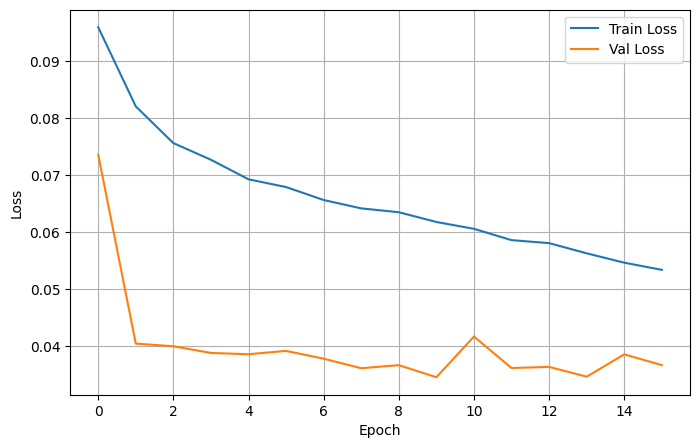

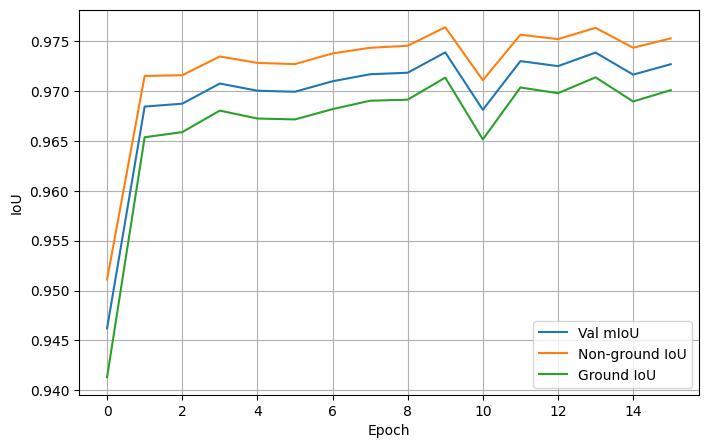

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_miou"], label="Val mIoU")
plt.plot(history["non_ground_iou"], label="Non-ground IoU")
plt.plot(history["ground_iou"], label="Ground IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.show()

## 11. Load the best ROD checkpoint

In [13]:
checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
    weights_only=False,
)

test_model = build_rod_model()
test_model.load_state_dict(checkpoint["model_state_dict"])
test_model = test_model.to(DEVICE)
test_model.eval()

print("Loaded checkpoint from:", best_model_path)
print("Best val mIoU:", checkpoint["best_val_miou"])
print("Checkpoint epoch:", checkpoint["epoch"])
print("Configured epochs:", checkpoint.get("epochs_configured", "not stored"))
print("Model device:", next(test_model.parameters()).device)

Loaded checkpoint from: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth
Best val mIoU: 0.9739020336321288
Checkpoint epoch: 10
Configured epochs: 20
Model device: cuda:0


## 12. Final RUGD test evaluation

The final test metrics use **dataset-level (global) accumulation over all valid pixels**, matching the final evaluation structure used by the other three models.

In [14]:
@torch.no_grad()
def evaluate_on_test_set(
    model,
    loader,
    criterion,
    device,
    num_classes=2,
    ignore_index=255,
):
    model.eval()

    total_loss = 0.0
    intersections = np.zeros(num_classes, dtype=np.float64)
    unions = np.zeros(num_classes, dtype=np.float64)
    tp = np.zeros(num_classes, dtype=np.float64)
    fp = np.zeros(num_classes, dtype=np.float64)
    fn = np.zeros(num_classes, dtype=np.float64)

    total_correct = 0
    total_valid = 0

    for images, masks in tqdm(loader, desc="Testing"):
        images = images.to(device, non_blocking=True).float()
        masks = masks.to(device, non_blocking=True).long()

        logits = model(images)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        preds_np = preds.detach().cpu().numpy()
        masks_np = masks.detach().cpu().numpy()
        valid = masks_np != ignore_index

        total_correct += ((preds_np == masks_np) & valid).sum()
        total_valid += valid.sum()

        for cls in range(num_classes):
            pred_cls = (preds_np == cls) & valid
            target_cls = (masks_np == cls) & valid

            cls_tp = np.logical_and(pred_cls, target_cls).sum()
            cls_fp = np.logical_and(
                pred_cls,
                np.logical_not(target_cls) & valid,
            ).sum()
            cls_fn = np.logical_and(
                np.logical_not(pred_cls) & valid,
                target_cls,
            ).sum()

            tp[cls] += cls_tp
            fp[cls] += cls_fp
            fn[cls] += cls_fn
            intersections[cls] += cls_tp
            unions[cls] += np.logical_or(pred_cls, target_cls).sum()

    class_ious = {}
    class_dice = {}
    class_precision = {}
    class_recall = {}

    for cls in range(num_classes):
        class_ious[cls] = (
            float(intersections[cls] / unions[cls])
            if unions[cls] > 0 else None
        )

        dice_denom = 2 * tp[cls] + fp[cls] + fn[cls]
        precision_denom = tp[cls] + fp[cls]
        recall_denom = tp[cls] + fn[cls]

        class_dice[cls] = (
            float((2 * tp[cls]) / dice_denom)
            if dice_denom > 0 else None
        )
        class_precision[cls] = (
            float(tp[cls] / precision_denom)
            if precision_denom > 0 else None
        )
        class_recall[cls] = (
            float(tp[cls] / recall_denom)
            if recall_denom > 0 else None
        )

    mean_iou = float(np.mean([v for v in class_ious.values() if v is not None]))
    mean_dice = float(np.mean([v for v in class_dice.values() if v is not None]))
    mean_precision = float(
        np.mean([v for v in class_precision.values() if v is not None])
    )
    mean_recall = float(
        np.mean([v for v in class_recall.values() if v is not None])
    )

    pixel_accuracy = float(total_correct / total_valid)
    test_loss = float(total_loss / len(loader.dataset))

    return (
        test_loss,
        mean_iou,
        class_ious,
        pixel_accuracy,
        mean_dice,
        mean_precision,
        mean_recall,
        class_dice,
        class_precision,
        class_recall,
    )


(
    test_loss,
    test_miou,
    test_class_iou,
    test_pixel_acc,
    test_mean_dice,
    test_mean_precision,
    test_mean_recall,
    test_class_dice,
    test_class_precision,
    test_class_recall,
) = evaluate_on_test_set(
    model=test_model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("\n===== Final Test Set Results =====")
print(f"Test Loss:            {test_loss:.4f}")
print(f"Non-ground IoU:       {test_class_iou[0]:.4f}")
print(f"Ground IoU:           {test_class_iou[1]:.4f}")
print(f"mIoU:                 {test_miou:.4f}")
print(f"Mean Dice:            {test_mean_dice:.4f}")
print(f"Mean Precision:       {test_mean_precision:.4f}")
print(f"Mean Recall:          {test_mean_recall:.4f}")
print(f"Pixel Accuracy:       {test_pixel_acc:.4f}")

print("\nPer-class metrics:")
print(
    f"Non-ground -> Dice={test_class_dice[0]:.4f}, "
    f"Precision={test_class_precision[0]:.4f}, "
    f"Recall={test_class_recall[0]:.4f}"
)
print(
    f"Ground     -> Dice={test_class_dice[1]:.4f}, "
    f"Precision={test_class_precision[1]:.4f}, "
    f"Recall={test_class_recall[1]:.4f}"
)

Testing:   0%|          | 0/1482 [00:00<?, ?it/s]


===== Final Test Set Results =====
Test Loss:            0.1255
Non-ground IoU:       0.9225
Ground IoU:           0.8847
mIoU:                 0.9036
Mean Dice:            0.9493
Mean Precision:       0.9485
Mean Recall:          0.9501
Pixel Accuracy:       0.9514

Per-class metrics:
Non-ground -> Dice=0.9597, Precision=0.9630, Recall=0.9564
Ground     -> Dice=0.9388, Precision=0.9339, Recall=0.9438


## 13. Inference speed

In [15]:
@torch.no_grad()
def measure_inference_speed(
    model,
    loader,
    device,
    warmup_batches=10,
):
    model.eval()

    iterator = iter(loader)
    warmup_done = 0

    while warmup_done < warmup_batches:
        try:
            images, _ = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            images, _ = next(iterator)

        images = images.to(device, non_blocking=True).float()

        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        warmup_done += 1

    total_time = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Measuring inference speed"):
        images = images.to(device, non_blocking=True).float()

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

        total_time += elapsed
        total_images += images.size(0)

    mean_inference_time_ms = 1000.0 * total_time / total_images
    fps = total_images / total_time

    print(f"Mean inference time: {mean_inference_time_ms:.3f} ms/image")
    print(f"FPS:                 {fps:.3f}")

    return float(mean_inference_time_ms), float(fps)


mean_inference_time_ms, fps = measure_inference_speed(
    model=test_model,
    loader=test_loader,
    device=DEVICE,
    warmup_batches=10,
)

Measuring inference speed:   0%|          | 0/1482 [00:00<?, ?it/s]

Mean inference time: 61.277 ms/image
FPS:                 16.319


## 14. Save test summary

In [16]:
test_results = {
    "model_name": MODEL_NAME,
    "encoder_name": ENCODER_NAME,
    "test_loss": float(test_loss),

    "non_ground_iou": float(test_class_iou[0]),
    "ground_iou": float(test_class_iou[1]),
    "miou": float(test_miou),

    "non_ground_dice": float(test_class_dice[0]),
    "ground_dice": float(test_class_dice[1]),
    "mean_dice": float(test_mean_dice),

    "non_ground_precision": float(test_class_precision[0]),
    "ground_precision": float(test_class_precision[1]),
    "mean_precision": float(test_mean_precision),

    "non_ground_recall": float(test_class_recall[0]),
    "ground_recall": float(test_class_recall[1]),
    "mean_recall": float(test_mean_recall),

    "pixel_accuracy": float(test_pixel_acc),

    "mean_inference_time_ms": float(mean_inference_time_ms),
    "fps": float(fps),

    "checkpoint_path": str(best_model_path),
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "best_val_miou": float(checkpoint["best_val_miou"]),
    "num_classes": NUM_CLASSES,
    "ignore_index": IGNORE_INDEX,
}

result_path = RESULTS_DIR / "test_summary.json"

with open(result_path, "w") as f:
    json.dump(test_results, f, indent=4)

print("Saved test results to:", result_path)
print(test_results)

Saved test results to: /content/drive/MyDrive/IRP/02_in_domain_rugd/results/rod_20epochs/test_summary.json
{'model_name': 'ROD', 'encoder_name': 'EfficientSAM-S', 'test_loss': 0.12545823323535363, 'non_ground_iou': 0.9225378025014774, 'ground_iou': 0.8847040977986814, 'miou': 0.9036209501500794, 'non_ground_dice': 0.9597083618341684, 'ground_dice': 0.9388254621317037, 'mean_dice': 0.949266911982936, 'non_ground_precision': 0.9630272989451676, 'ground_precision': 0.9339385503494178, 'mean_precision': 0.9484829246472927, 'non_ground_recall': 0.9564122226461822, 'ground_recall': 0.9437637852796802, 'mean_recall': 0.9500880039629311, 'pixel_accuracy': 0.9514158818023787, 'mean_inference_time_ms': 61.276590076243195, 'fps': 16.319445954087087, 'checkpoint_path': '/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth', 'checkpoint_epoch': 10, 'best_val_miou': 0.9739020336321288, 'num_classes': 2, 'ignore_index': 255}


## 15. Per-image metrics and Top-5 / Bottom-5 ranking

In [17]:
def compute_single_image_metrics(
    pred,
    target,
    num_classes=2,
    ignore_index=255,
):
    valid = target != ignore_index
    class_ious = {}

    for cls in range(num_classes):
        pred_cls = (pred == cls) & valid
        target_cls = (target == cls) & valid

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        class_ious[cls] = (
            None if union == 0 else float(intersection / union)
        )

    valid_ious = [
        iou for iou in class_ious.values()
        if iou is not None
    ]

    miou = float(np.mean(valid_ious)) if valid_ious else None

    valid_pixels = int(valid.sum())
    pixel_accuracy = (
        float(((pred == target) & valid).sum() / valid_pixels)
        if valid_pixels > 0 else None
    )

    return miou, class_ious, pixel_accuracy, valid_pixels


@torch.no_grad()
def evaluate_each_test_image(
    model,
    dataset,
    device,
    num_classes=2,
    ignore_index=255,
):
    model.eval()
    results = []

    for idx in tqdm(
        range(len(dataset)),
        desc="Evaluating each test image",
    ):
        image, mask = dataset[idx]

        logits = model(
            image.unsqueeze(0).to(device).float()
        )
        pred = (
            torch.argmax(logits, dim=1)
            .squeeze(0)
            .cpu()
            .numpy()
        )
        mask_np = mask.cpu().numpy()

        miou, class_ious, pixel_accuracy, valid_pixels = (
            compute_single_image_metrics(
                pred=pred,
                target=mask_np,
                num_classes=num_classes,
                ignore_index=ignore_index,
            )
        )

        image_path = (
            dataset.image_paths[idx]
            if hasattr(dataset, "image_paths")
            else None
        )

        results.append({
            "idx": idx,
            "image_path": (
                str(image_path)
                if image_path is not None
                else None
            ),
            "miou": miou,
            "non_ground_iou": class_ious[0],
            "ground_iou": class_ious[1],
            "pixel_accuracy": pixel_accuracy,
            "valid_pixels": valid_pixels,
        })

    return results


per_image_results = evaluate_each_test_image(
    model=test_model,
    dataset=test_dataset,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)


def format_iou(value):
    if value is None:
        return "None"
    return f"{value:.4f}"


valid_results = [
    r for r in per_image_results
    if r["miou"] is not None
]

top5_best = sorted(
    valid_results,
    key=lambda x: x["miou"],
    reverse=True,
)[:5]

bottom5_worst = sorted(
    valid_results,
    key=lambda x: x["miou"],
)[:5]

print("===== Top-5 Best Test Images =====")
for rank, r in enumerate(top5_best, 1):
    print(
        f"rank={rank}, idx={r['idx']}, "
        f"mIoU={format_iou(r['miou'])}, "
        f"non-ground IoU={format_iou(r['non_ground_iou'])}, "
        f"ground IoU={format_iou(r['ground_iou'])}, "
        f"pixel accuracy={format_iou(r['pixel_accuracy'])}, "
        f"path={r['image_path']}"
    )

print("\n===== Bottom-5 Worst Test Images =====")
for rank, r in enumerate(bottom5_worst, 1):
    print(
        f"rank={rank}, idx={r['idx']}, "
        f"mIoU={format_iou(r['miou'])}, "
        f"non-ground IoU={format_iou(r['non_ground_iou'])}, "
        f"ground IoU={format_iou(r['ground_iou'])}, "
        f"pixel accuracy={format_iou(r['pixel_accuracy'])}, "
        f"path={r['image_path']}"
    )

Evaluating each test image:   0%|          | 0/1482 [00:00<?, ?it/s]

===== Top-5 Best Test Images =====
rank=1, idx=1464, mIoU=0.9970, non-ground IoU=0.9970, ground IoU=0.9969, pixel accuracy=0.9985, path=/content/content/RUGD_processed/images/test/village_village_00498.png
rank=2, idx=1449, mIoU=0.9967, non-ground IoU=0.9969, ground IoU=0.9965, pixel accuracy=0.9984, path=/content/content/RUGD_processed/images/test/village_village_00423.png
rank=3, idx=1421, mIoU=0.9966, non-ground IoU=0.9968, ground IoU=0.9964, pixel accuracy=0.9983, path=/content/content/RUGD_processed/images/test/village_village_00283.png
rank=4, idx=1428, mIoU=0.9962, non-ground IoU=0.9971, ground IoU=0.9954, pixel accuracy=0.9982, path=/content/content/RUGD_processed/images/test/village_village_00318.png
rank=5, idx=1419, mIoU=0.9961, non-ground IoU=0.9963, ground IoU=0.9960, pixel accuracy=0.9981, path=/content/content/RUGD_processed/images/test/village_village_00273.png

===== Bottom-5 Worst Test Images =====
rank=1, idx=694, mIoU=0.3127, non-ground IoU=0.6254, ground IoU=0.0000

## 16. Five-column Top-5 / Bottom-5 visualisation

In [18]:
def make_binary_vis(mask):
    # 0=non-ground (black), 1=ground (white), 255=ignore (gray)
    vis = np.zeros_like(mask, dtype=np.uint8)
    vis[mask == 0] = 0
    vis[mask == 1] = 1
    vis[mask == 255] = 2
    return vis


def make_error_map(pred, target, ignore_index=255):
    # black=correct/ignored, red=false ground, blue=false non-ground
    error_rgb = np.zeros((*target.shape, 3), dtype=np.uint8)
    valid = target != ignore_index

    false_ground = (target == 0) & (pred == 1) & valid
    false_non_ground = (target == 1) & (pred == 0) & valid

    error_rgb[false_ground] = [255, 0, 0]
    error_rgb[false_non_ground] = [0, 0, 255]

    return error_rgb


def denormalize_image(image_tensor):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = image_np * PIXEL_STD + PIXEL_MEAN
    image_np = np.clip(image_np / 255.0, 0, 1)
    return image_np


def make_prediction_overlay(image_np, pred, alpha=0.42):
    overlay = image_np.copy()
    ground = pred == 1

    green = np.zeros_like(image_np)
    green[..., 1] = 1.0

    overlay[ground] = (
        (1.0 - alpha) * image_np[ground]
        + alpha * green[ground]
    )

    return np.clip(overlay, 0, 1)


@torch.no_grad()
def visualize_selected_test_samples(
    model,
    dataset,
    device,
    selected_results,
    title_prefix="",
    save_dir=None,
):
    # Five columns:
    # RGB | GT ground | ROD prediction | prediction overlay | errors
    model.eval()

    binary_cmap = ListedColormap(["black", "white", "gray"])

    for rank, r in enumerate(selected_results, 1):
        idx = r["idx"]
        image, mask = dataset[idx]

        logits = model(
            image.unsqueeze(0).to(device).float()
        )
        pred = (
            torch.argmax(logits, dim=1)
            .squeeze(0)
            .cpu()
            .numpy()
        )

        mask_np = mask.cpu().numpy()
        image_np = denormalize_image(image)

        mask_vis = make_binary_vis(mask_np)
        overlay = make_prediction_overlay(image_np, pred)
        error_map = make_error_map(
            pred,
            mask_np,
            ignore_index=IGNORE_INDEX,
        )

        fig, axes = plt.subplots(
            1,
            5,
            figsize=(25, 5),
        )

        path_text = (
            r["image_path"]
            if r["image_path"] is not None
            else f"idx={idx}"
        )

        fig.suptitle(
            f"{title_prefix} #{rank} | {path_text}\n"
            f"mIoU={format_iou(r['miou'])}, "
            f"non-ground IoU={format_iou(r['non_ground_iou'])}, "
            f"ground IoU={format_iou(r['ground_iou'])}",
            fontsize=11,
            y=1.04,
        )

        axes[0].imshow(image_np)
        axes[0].set_title("RGB")

        axes[1].imshow(
            mask_vis,
            cmap=binary_cmap,
            vmin=0,
            vmax=2,
        )
        axes[1].set_title(
            "GT ground\n"
            "white=ground, gray=ignore"
        )

        axes[2].imshow(
            pred,
            cmap=ListedColormap(["black", "white"]),
            vmin=0,
            vmax=1,
        )
        axes[2].set_title("ROD prediction")

        axes[3].imshow(overlay)
        axes[3].set_title(
            "Prediction overlay\n"
            "green=predicted ground"
        )

        axes[4].imshow(error_map)
        axes[4].set_title(
            "Errors\n"
            "red=false ground\n"
            "blue=false non-ground"
        )

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)

            safe_prefix = (
                title_prefix.lower()
                .replace(" ", "_")
                .replace("-", "")
            )

            out_path = (
                save_dir
                / f"{safe_prefix}_rank_{rank:02d}_idx_{idx}.png"
            )

            plt.savefig(
                out_path,
                dpi=200,
                bbox_inches="tight",
            )
            print("Saved:", out_path)

        plt.show()


RANKED_VIS_DIR = RESULTS_DIR / "ranked_cases"
RANKED_VIS_DIR.mkdir(parents=True, exist_ok=True)

visualize_selected_test_samples(
    model=test_model,
    dataset=test_dataset,
    device=DEVICE,
    selected_results=top5_best,
    title_prefix="Top-5 Best",
    save_dir=RANKED_VIS_DIR,
)

visualize_selected_test_samples(
    model=test_model,
    dataset=test_dataset,
    device=DEVICE,
    selected_results=bottom5_worst,
    title_prefix="Bottom-5 Worst",
    save_dir=RANKED_VIS_DIR,
)

Output hidden; open in https://colab.research.google.com to view.

## 17. Save per-image results and mIoU distribution

Saved per-image metrics to: /content/drive/MyDrive/IRP/02_in_domain_rugd/results/rod_20epochs/test_per_image_metrics.csv


,idx,image_path,miou,non_ground_iou,ground_iou,pixel_accuracy,valid_pixels
0,0,/content/content/RUGD_processed/images/test/cr...,0.857335,0.890108,0.824563,0.927536,208820
1,1,/content/content/RUGD_processed/images/test/cr...,0.858255,0.891173,0.825337,0.928131,208796
2,2,/content/content/RUGD_processed/images/test/cr...,0.828874,0.869481,0.788268,0.912162,208578
3,3,/content/content/RUGD_processed/images/test/cr...,0.891033,0.924668,0.857397,0.948152,206777
4,4,/content/content/RUGD_processed/images/test/cr...,0.895654,0.918489,0.872820,0.947729,204129


Saved histogram to: /content/drive/MyDrive/IRP/02_in_domain_rugd/results/rod_20epochs/per_image_miou_distribution.png


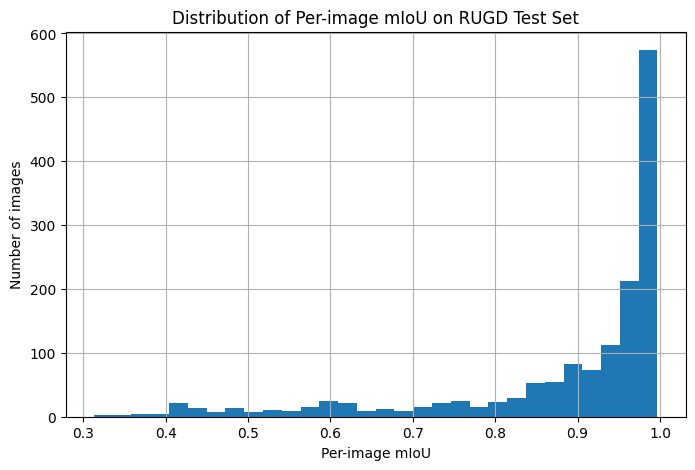

In [19]:
df_results = pd.DataFrame(per_image_results)

csv_path = RESULTS_DIR / "test_per_image_metrics.csv"
df_results.to_csv(csv_path, index=False)

print("Saved per-image metrics to:", csv_path)
display(df_results.head())

plt.figure(figsize=(8, 5))
plt.hist(df_results["miou"].dropna(), bins=30)
plt.xlabel("Per-image mIoU")
plt.ylabel("Number of images")
plt.title("Distribution of Per-image mIoU on RUGD Test Set")
plt.grid(True)

hist_path = RESULTS_DIR / "per_image_miou_distribution.png"
plt.savefig(
    hist_path,
    dpi=200,
    bbox_inches="tight",
)

print("Saved histogram to:", hist_path)
plt.show()

## Output files

- Best checkpoint: `/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth`
- Test summary: `.../results/rod_20epochs/test_summary.json`
- Per-image metrics: `.../results/rod_20epochs/test_per_image_metrics.csv`
- Ranked cases: `.../results/rod_20epochs/ranked_cases/`
- Per-image mIoU histogram: `.../results/rod_20epochs/per_image_miou_distribution.png`